In [1]:
# Импорт необходимых библиотек
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, isnan, when, count, lit, rand
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType, TimestampType
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

In [2]:
# Инициализация Spark Session
spark = SparkSession.builder \
    .appName("Data Preprocessing") \
    .getOrCreate()

# Блок 1. Исходные данные

# 1. Генерация подходящего набора данных

In [9]:
def generate_ecommerce_data(num_records=1000, seed=42):
    """
    Генерирует данные о клиентах и покупках в интернет-магазине
    с преднамеренными проблемами для демонстрации предварительной обработки
    """
    # Для воспроизводимости результатов
    np.random.seed(seed)
    random.seed(seed)

    # Категории продуктов
    categories = ['Electronics', 'Books', 'Clothing', 'Home & Kitchen', 'Beauty', 'Sports']
    countries = ['USA', 'Canada', 'UK', 'Germany', 'France', 'Australia', 'Japan', 'China']

    # Создание базовых данных
    data = {
        'customer_id': [f'CUST{i:05d}' for i in range(1, num_records+1)],
        'age': np.random.randint(18, 80, num_records),
        'gender': [random.choice(['M', 'F', None]) for _ in range(num_records)],  # Добавляем None для пропущенных значений
        'country': [random.choice(countries) for _ in range(num_records)],
        'product_category': [random.choice(categories) for _ in range(num_records)],
        'purchase_amount': np.random.uniform(10, 500, num_records).round(2),
        'items_count': np.random.randint(1, 10, num_records),
        'discount_applied': np.random.choice([True, False], num_records),
        'satisfaction_score': [random.choice([1, 2, 3, 4, 5, None]) for _ in range(num_records)],  # Рейтинг от 1 до 5 с пропусками
    }

    # Генерация временных меток за последний год
    now = datetime.now()
    one_year_ago = now - timedelta(days=365)
    timestamps = [one_year_ago + timedelta(days=random.randint(0, 365),
                                           hours=random.randint(0, 23),
                                           minutes=random.randint(0, 59))
                 for _ in range(num_records)]
    data['purchase_date'] = timestamps

    # Намеренно добавляем проблемы с типами данных для демонстрации
    # Случайные строки, где числовые значения представлены строками
    for i in np.random.choice(range(num_records), size=int(num_records*0.05)):
        if random.random() < 0.5:
            data['age'][i] = str(data['age'][i])
        else:
            data['purchase_amount'][i] = str(data['purchase_amount'][i])

    # Добавление полностью пустой колонки
    data['temp_notes'] = [None] * num_records

    # Добавление колонки с большим количеством пропусков
    data['shipping_address'] = [random.choice([f'Address-{i}', None])
                               for i in range(num_records)]

    # Намеренное добавление дубликатов (около 10% данных)
    duplicate_indices = np.random.choice(range(num_records),
                                        size=int(num_records*0.1),
                                        replace=False)

    for idx in duplicate_indices:
        # Создаем копию строки и добавляем её в данные
        for col_name in data:
            if col_name != 'customer_id': # Сохраняем уникальность customer_id
                # data[col_name].concatenate(data[col_name][idx])
                data[col_name] = np.append(data[col_name], data[col_name][idx])

        data['customer_id'].append(f'CUST{len(data["customer_id"]):05d}')

    # Преобразование в pandas DataFrame
    df = pd.DataFrame(data)

    return df

# Генерация данных
data_pd = generate_ecommerce_data(num_records=1000)
print(f"Размер сгенерированных данных: {data_pd.shape}")
data_pd.head()

Размер сгенерированных данных: (1100, 12)


,customer_id,age,gender,country,product_category,purchase_amount,items_count,discount_applied,satisfaction_score,purchase_date,temp_notes,shipping_address
0,CUST00001,56,None,Japan,Home & Kitchen,194.60,3,True,1,2024-11-09 08:51:46.656428,None,Address-0
1,CUST00002,69,M,Germany,Beauty,377.29,4,True,1,2024-07-04 07:17:46.656428,None,Address-1
2,CUST00003,46,M,Japan,Sports,202.56,5,True,1,2025-03-05 12:15:46.656428,None,Address-2
3,CUST00004,32,None,China,Sports,416.29,6,True,3,2025-04-29 22:37:46.656428,None,Address-3
4,CUST00005,60,F,China,Home & Kitchen,288.85,3,True,2,2024-12-30 18:18:46.656428,None,Address-4


# 2. Считываем данные в Spark DataFrame и проверяем типы

In [11]:
# Определяем схему явно
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType, BooleanType, TimestampType

# Создаем схему
schema = StructType([
    StructField("customer_id", StringType(), True),
    StructField("age", StringType(), True),  # Используем StringType, чтобы принять как числа, так и строки
    StructField("gender", StringType(), True),
    StructField("country", StringType(), True),
    StructField("product_category", StringType(), True),
    StructField("purchase_amount", StringType(), True),  # Используем StringType для смешанных типов
    StructField("items_count", IntegerType(), True),
    StructField("discount_applied", BooleanType(), True),
    StructField("satisfaction_score", IntegerType(), True),
    StructField("purchase_date", TimestampType(), True),
    StructField("temp_notes", StringType(), True),
    StructField("shipping_address", StringType(), True)
])

# Преобразование с явной схемой
df = spark.createDataFrame(data_pd, schema=schema)

# Проверка схемы и типов данных
print("Схема DataFrame:")
df.printSchema()

# Проверка размера данных
print(f"Количество строк: {df.count()}")
print(f"Количество столбцов: {len(df.columns)}")

# Базовая статистика и проверка пропущенных значений
print("\nСтатистика по пропущенным значениям:")
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

Схема DataFrame:
root
 |-- customer_id: string (nullable = true)
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- purchase_amount: string (nullable = true)
 |-- items_count: integer (nullable = true)
 |-- discount_applied: boolean (nullable = true)
 |-- satisfaction_score: integer (nullable = true)
 |-- purchase_date: timestamp (nullable = true)
 |-- temp_notes: string (nullable = true)
 |-- shipping_address: string (nullable = true)

Количество строк: 1100
Количество столбцов: 12

Статистика по пропущенным значениям:
+-----------+---+------+-------+----------------+---------------+-----------+----------------+------------------+-------------+----------+----------------+
|customer_id|age|gender|country|product_category|purchase_amount|items_count|discount_applied|satisfaction_score|purchase_date|temp_notes|shipping_address|
+-----------+---+------+-------+----------------

# 3. Преобразование типов данных

In [12]:
# Проверяем, какие значения требуют преобразования
print("Примеры значений в колонке age:")
df.select("age").distinct().limit(10).show()

print("Примеры значений в колонке purchase_amount:")
df.select("purchase_amount").distinct().limit(10).show()

# Преобразование типов
df_converted = df \
    .withColumn("age", col("age").cast(IntegerType())) \
    .withColumn("purchase_amount", col("purchase_amount").cast(FloatType())) \
    .withColumn("satisfaction_score", col("satisfaction_score").cast(IntegerType()))

# Проверка результатов преобразования
print("\nСхема после преобразования типов:")
df_converted.printSchema()

# Проверка значений после преобразования
print("Примеры значений в колонке age после преобразования:")
df_converted.select("age").distinct().limit(5).show()

Примеры значений в колонке age:
+---+
|age|
+---+
| 51|
| 54|
| 69|
| 29|
| 42|
| 73|
| 64|
| 30|
| 34|
| 59|
+---+

Примеры значений в колонке purchase_amount:
+---------------+
|purchase_amount|
+---------------+
|         487.78|
|         184.13|
|         287.23|
|         194.87|
|         377.31|
|          254.1|
|         490.43|
|         274.49|
|         256.12|
|         381.93|
+---------------+


Схема после преобразования типов:
root
 |-- customer_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- purchase_amount: float (nullable = true)
 |-- items_count: integer (nullable = true)
 |-- discount_applied: boolean (nullable = true)
 |-- satisfaction_score: integer (nullable = true)
 |-- purchase_date: timestamp (nullable = true)
 |-- temp_notes: string (nullable = true)
 |-- shipping_address: string (nullable = true)

Примеры значе

# 4. Предварительная обработка данных

## 4.1 Расчет и замена средним по колонке (для age)


In [13]:
# Сначала посчитаем среднее значение возраста
mean_age = df_converted.select(avg("age")).first()[0]
print(f"Среднее значение возраста: {mean_age:.2f}")

# Заменяем пропущенные значения средним
df_processed = df_converted.withColumn(
    "age",
    when(col("age").isNull(), mean_age).otherwise(col("age"))
)

Среднее значение возраста: 50.04


## 4.2 Удаление колонки с отсутствующими значениями

In [14]:
# Удаляем колонку temp_notes, которая полностью состоит из NULL
df_processed = df_processed.drop("temp_notes")

## 4.3 Удаление строк с отсутствующими значениями для satisfaction_score

In [15]:
df_processed = df_processed.filter(col("satisfaction_score").isNotNull())

## 4.4 Удаление дубликатов

In [16]:
# Проверяем количество дубликатов перед удалением
duplicates_count = df_processed.count() - df_processed.dropDuplicates().count()
print(f"Найдено {duplicates_count} дубликатов")

# Удаляем дубликаты
df_processed = df_processed.dropDuplicates()

Найдено 0 дубликатов


In [17]:
# Сохраняем обработанный набор данных для использования в следующих блоках
df_processed.write.mode("overwrite").parquet("processed_ecommerce_data")
print("Данные сохранены в формате parquet для дальнейшего использования")

Данные сохранены в формате parquet для дальнейшего использования


# Блок 2. Базовые запросы

In [18]:
# Загрузка обработанного набора данных из предыдущего блока
df_processed = spark.read.parquet("processed_ecommerce_data")

# Проверка структуры данных
print("Схема загруженных данных:")
df_processed.printSchema()

# Показать несколько строк для ознакомления
print("\nПример данных:")
df_processed.show(5)

Схема загруженных данных:
root
 |-- customer_id: string (nullable = true)
 |-- age: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- purchase_amount: float (nullable = true)
 |-- items_count: integer (nullable = true)
 |-- discount_applied: boolean (nullable = true)
 |-- satisfaction_score: integer (nullable = true)
 |-- purchase_date: timestamp (nullable = true)
 |-- shipping_address: string (nullable = true)


Пример данных:
+-----------+----+------+---------+----------------+---------------+-----------+----------------+------------------+--------------------+----------------+
|customer_id| age|gender|  country|product_category|purchase_amount|items_count|discount_applied|satisfaction_score|       purchase_date|shipping_address|
+-----------+----+------+---------+----------------+---------------+-----------+----------------+------------------+--------------------+----------------

# 1. Выполнение фильтрации по данным

In [19]:
# Фильтрация 1: Дорогие покупки в категории Electronics с высоким рейтингом
expensive_electronics = df_processed.filter(
    (df_processed.product_category == "Electronics") &
    (df_processed.purchase_amount > 300) &
    (df_processed.satisfaction_score >= 4)
)

print("Дорогие покупки электроники с высоким рейтингом:")
print(f"Количество строк: {expensive_electronics.count()}")
expensive_electronics.show(5)

# Фильтрация 2: Покупки клиентов из определенных стран в последние 6 месяцев
from pyspark.sql.functions import current_timestamp, months_between

recent_purchases = df_processed.filter(
    (df_processed.country.isin("USA", "UK", "Canada")) &
    (months_between(current_timestamp(), df_processed.purchase_date) <= 6)
)

print("\nНедавние покупки клиентов из США, Великобритании и Канады:")
print(f"Количество строк: {recent_purchases.count()}")
recent_purchases.show(5)

# Фильтрация 3: Покупки со скидкой молодых клиентов
young_discounted = df_processed.filter(
    (df_processed.age < 30) &
    (df_processed.discount_applied == True)
)

print("\nПокупки со скидкой клиентов младше 30 лет:")
print(f"Количество строк: {young_discounted.count()}")
young_discounted.select("customer_id", "age", "product_category", "purchase_amount").show(5)

Дорогие покупки электроники с высоким рейтингом:
Количество строк: 23
+-----------+----+------+---------+----------------+---------------+-----------+----------------+------------------+--------------------+----------------+
|customer_id| age|gender|  country|product_category|purchase_amount|items_count|discount_applied|satisfaction_score|       purchase_date|shipping_address|
+-----------+----+------+---------+----------------+---------------+-----------+----------------+------------------+--------------------+----------------+
|  CUST00112|74.0|     F|      USA|     Electronics|         346.71|          3|           false|                 5|2025-01-30 16:22:...|     Address-111|
|  CUST00409|71.0|     F|    Japan|     Electronics|         352.43|          2|            true|                 4|2024-12-21 01:28:...|     Address-408|
|  CUST00239|18.0|     M|      USA|     Electronics|         373.32|          3|            true|                 5|2024-09-30 04:11:...|     Address-238|


# 2. Выполнение группировок с расчетом агрегированных значений

In [20]:
from pyspark.sql.functions import avg, max, min, count, sum, round as round_

In [21]:
# Группировка 1: Анализ покупок по категориям продуктов
category_stats = df_processed.groupBy("product_category").agg(
    count("*").alias("total_purchases"),
    round_(avg("purchase_amount"), 2).alias("avg_amount"),
    round_(sum("purchase_amount"), 2).alias("total_revenue"),
    min("purchase_amount").alias("min_amount"),
    max("purchase_amount").alias("max_amount"),
    round_(avg("satisfaction_score"), 2).alias("avg_satisfaction")
).orderBy("total_revenue", ascending=False)

print("Статистика покупок по категориям продуктов:")
category_stats.show()

# Группировка 2: Анализ покупок по странам
country_stats = df_processed.groupBy("country").agg(
    count("*").alias("total_purchases"),
    round_(avg("purchase_amount"), 2).alias("avg_amount"),
    round_(sum("purchase_amount"), 2).alias("total_revenue"),
    round_(avg("age"), 1).alias("avg_customer_age")
).orderBy("total_purchases", ascending=False)

print("\nСтатистика покупок по странам:")
country_stats.show()

# Группировка 3: Анализ влияния скидок на объем покупок и удовлетворенность
discount_impact = df_processed.groupBy("discount_applied").agg(
    count("*").alias("total_purchases"),
    round_(avg("purchase_amount"), 2).alias("avg_amount"),
    round_(avg("items_count"), 2).alias("avg_items_count"),
    round_(avg("satisfaction_score"), 2).alias("avg_satisfaction")
)

print("\nВлияние скидок на покупки и удовлетворенность:")
discount_impact.show()

Статистика покупок по категориям продуктов:
+----------------+---------------+----------+-------------+----------+----------+----------------+
|product_category|total_purchases|avg_amount|total_revenue|min_amount|max_amount|avg_satisfaction|
+----------------+---------------+----------+-------------+----------+----------+----------------+
|          Sports|            162|    284.23|     46045.09|     10.55|    495.56|             2.8|
|          Beauty|            166|     265.1|      44005.9|     13.69|    498.87|            2.78|
|  Home & Kitchen|            151|    278.78|     42096.29|      10.6|    495.27|            2.99|
|           Books|            149|    254.57|     37930.97|     10.12|    498.66|            2.83|
|        Clothing|            150|    250.66|      37598.3|     12.52|    499.68|            3.11|
|     Electronics|            128|     241.9|     30962.66|     12.57|    495.82|            3.07|
+----------------+---------------+----------+-------------+------

# Блок 3. Анализ числовых данных

In [24]:
# Импорт необходимых библиотек
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, mean, stddev, min, max, skewness, kurtosis, corr
from pyspark.sql.types import DoubleType
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка предобработанного датафрейма
spark = SparkSession.builder.appName("Numerical Analysis").getOrCreate()
df_processed = spark.read.parquet("processed_ecommerce_data")

# Проверим структуру данных
print("Схема данных:")
df_processed.printSchema()

Схема данных:
root
 |-- customer_id: string (nullable = true)
 |-- age: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- purchase_amount: float (nullable = true)
 |-- items_count: integer (nullable = true)
 |-- discount_applied: boolean (nullable = true)
 |-- satisfaction_score: integer (nullable = true)
 |-- purchase_date: timestamp (nullable = true)
 |-- shipping_address: string (nullable = true)



# 3.1. Расчет числовых характеристик, включая асимметрию и эксцесс

In [32]:
# Определяем числовые колонки
numeric_columns = [field.name for field in df_processed.schema.fields
                  if field.dataType.typeName() in ['integer', 'double', 'float', 'long']]

print(f"Числовые колонки: {numeric_columns}")

stat_columns = []
for c in numeric_columns:
    stat_columns.extend([
        mean(col(c)).alias(f"{c}_mean"),
        stddev(col(c)).alias(f"{c}_stddev"),
        min(col(c)).alias(f"{c}_min"),
        max(col(c)).alias(f"{c}_max"),
        skewness(col(c)).alias(f"{c}_skewness"),
        kurtosis(col(c)).alias(f"{c}_kurtosis")
    ])

numeric_stats = df_processed.select(stat_columns)

# Транспонируем результаты для лучшей читаемости
numeric_stats_pd = numeric_stats.toPandas()
stats_dict = {}

for c in numeric_columns:
    stats_dict[c] = {
        'mean': numeric_stats_pd[f"{c}_mean"].iloc[0],
        'stddev': numeric_stats_pd[f"{c}_stddev"].iloc[0],
        'min': numeric_stats_pd[f"{c}_min"].iloc[0],
        'max': numeric_stats_pd[f"{c}_max"].iloc[0],
        'skewness': numeric_stats_pd[f"{c}_skewness"].iloc[0],
        'kurtosis': numeric_stats_pd[f"{c}_kurtosis"].iloc[0]
    }

# Преобразуем словарь в pandas DataFrame для удобного отображения
stats_df = pd.DataFrame(stats_dict).T
stats_df = stats_df.round(4)  # Округляем до 4 знаков

print("\nЧисловые характеристики:")
print(stats_df)

Числовые колонки: ['age', 'purchase_amount', 'items_count', 'satisfaction_score']

Числовые характеристики:
                        mean    stddev    min     max  skewness  kurtosis
age                  49.9978   17.9130  18.00   79.00   -0.0740   -1.1395
purchase_amount     263.3987  141.7277  10.12  499.68   -0.1266   -1.1393
items_count           5.0132    2.5619   1.00    9.00    0.0216   -1.2038
satisfaction_score    2.9249    1.4020   1.00    5.00    0.0854   -1.2719


# 3.2. Расчет матрицы корреляции для числовых признаков

In [33]:
# Создаем список всех пар числовых колонок для расчета корреляции
correlation_list = []

for i in range(len(numeric_columns)):
    for j in range(i, len(numeric_columns)):
        col1 = numeric_columns[i]
        col2 = numeric_columns[j]

        if col1 != col2:  # Избегаем расчета корреляции колонки с самой собой
            corr_value = df_processed.select(corr(col1, col2)).collect()[0][0]
            correlation_list.append((col1, col2, corr_value))

# Преобразуем результаты в матрицу корреляции
corr_matrix = np.zeros((len(numeric_columns), len(numeric_columns)))
corr_matrix_pd = pd.DataFrame(corr_matrix,
                             index=numeric_columns,
                             columns=numeric_columns)

# Заполняем матрицу корреляции
for col1, col2, corr_value in correlation_list:
    corr_matrix_pd.loc[col1, col2] = corr_value
    corr_matrix_pd.loc[col2, col1] = corr_value  # Матрица симметрична

# Диагональ - корреляция колонки с самой собой всегда 1
for col in numeric_columns:
    corr_matrix_pd.loc[col, col] = 1.0

print("\nМатрица корреляции:")
print(corr_matrix_pd.round(3))


Матрица корреляции:
                      age  purchase_amount  items_count  satisfaction_score
age                 1.000           -0.017        0.004              -0.011
purchase_amount    -0.017            1.000       -0.034              -0.016
items_count         0.004           -0.034        1.000               0.002
satisfaction_score -0.011           -0.016        0.002               1.000


# 3.3. Визуализация полученных расчетов

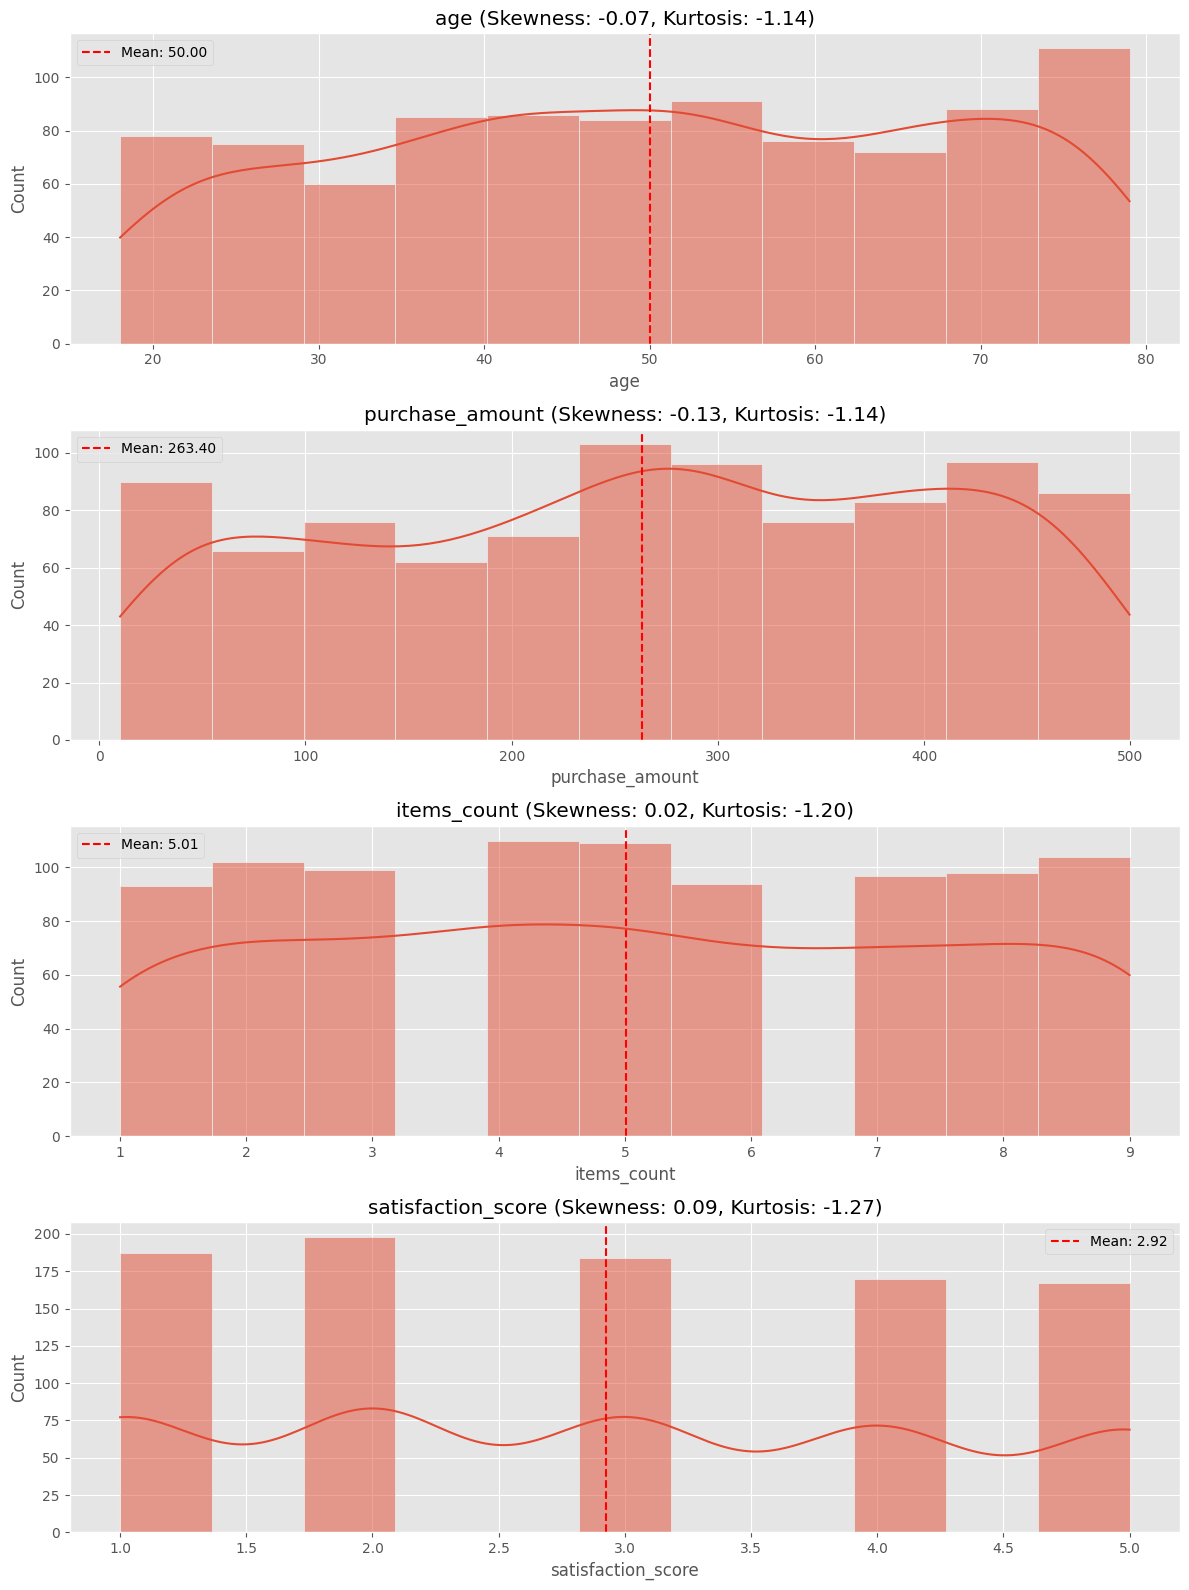

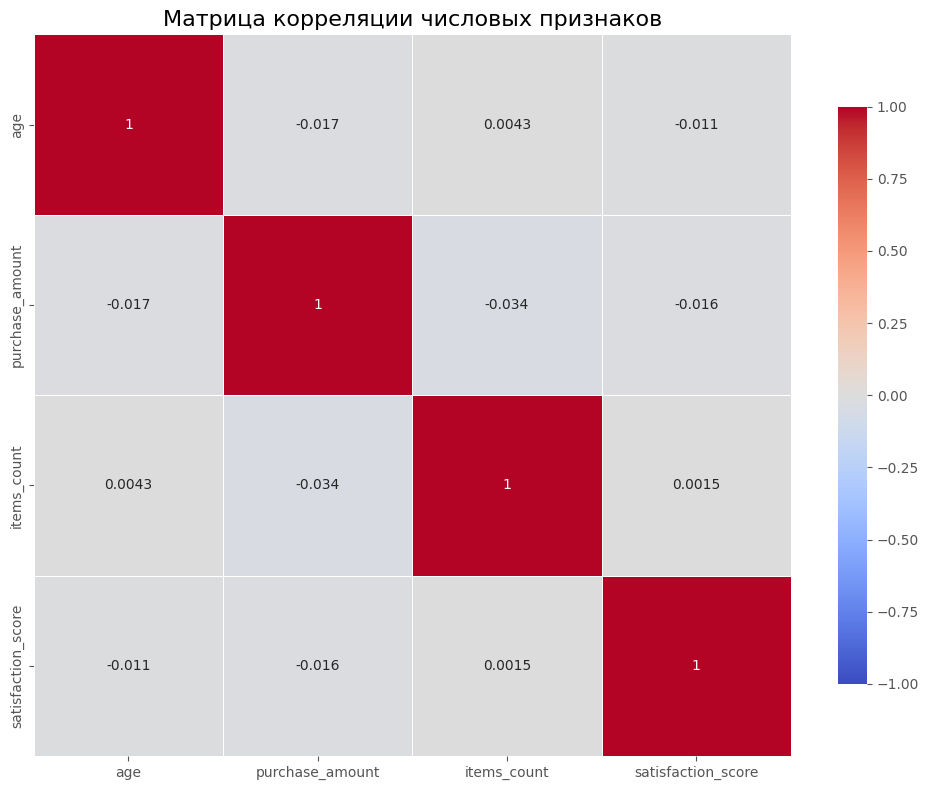

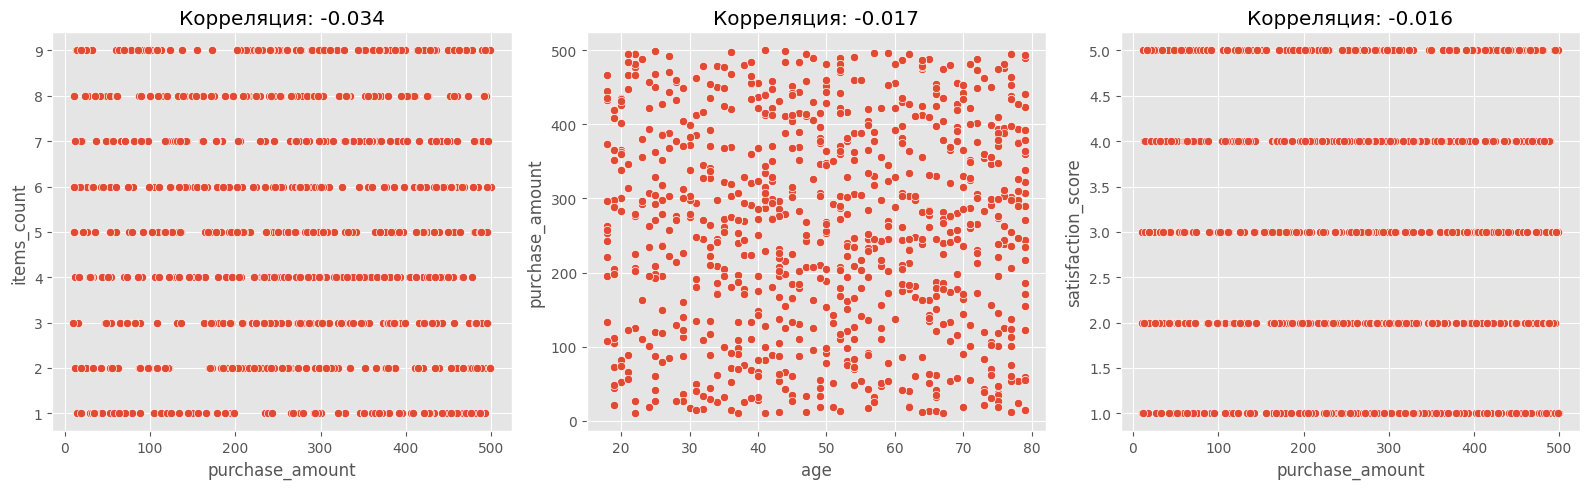

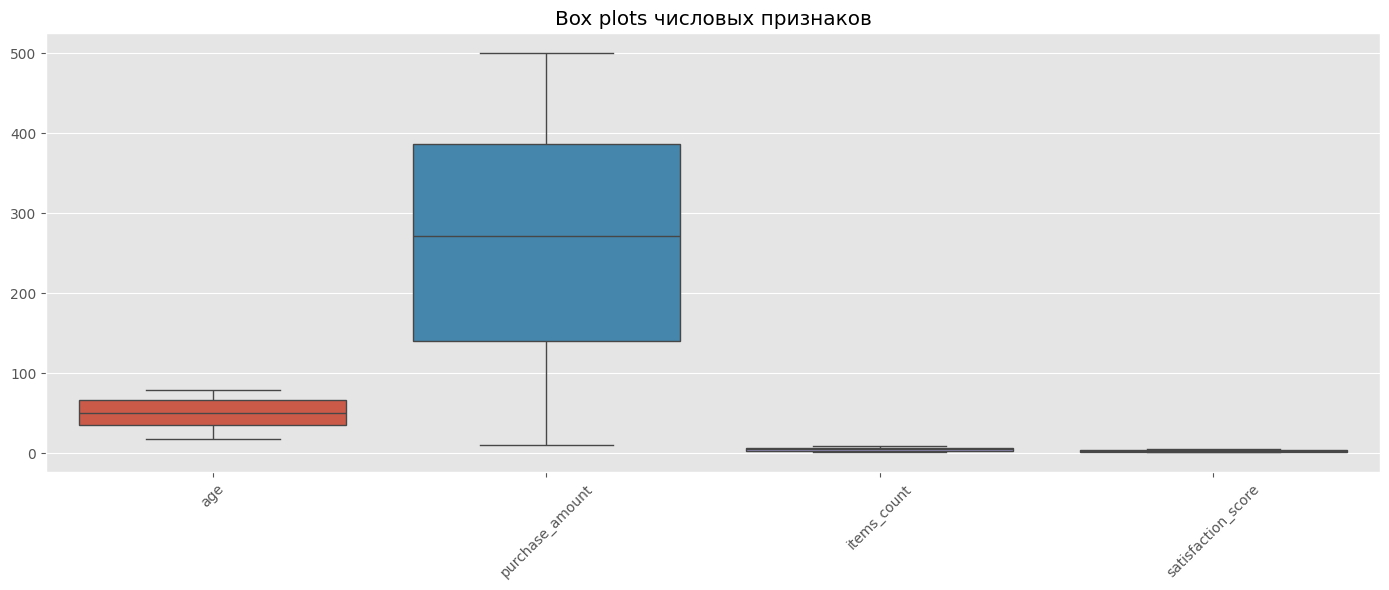

In [34]:
# Преобразуем Spark DataFrame в pandas для визуализации
pandas_df = df_processed.select(numeric_columns).toPandas()

# Настраиваем стиль графиков
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 10)

# 3.1 Гистограммы распределения числовых признаков с отображением асимметрии и эксцесса
fig, axes = plt.subplots(nrows=len(numeric_columns), ncols=1, figsize=(12, 4*len(numeric_columns)))

for i, column in enumerate(numeric_columns):
    # Получаем статистики для заголовка
    mean_val = stats_df.loc[column, 'mean']
    skew = stats_df.loc[column, 'skewness']
    kurt = stats_df.loc[column, 'kurtosis']

    # Строим гистограмму
    sns.histplot(pandas_df[column], kde=True, ax=axes[i])
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].set_title(f'{column} (Skewness: {skew:.2f}, Kurtosis: {kurt:.2f})')
    axes[i].legend()

plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

# 3.2 Тепловая карта корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_pd, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
           linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции числовых признаков', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# 3.3 Диаграммы рассеяния для наиболее коррелированных пар признаков
# Находим топ-3 пары с наибольшей абсолютной корреляцией
corr_pairs = []
for i in range(len(numeric_columns)):
    for j in range(i+1, len(numeric_columns)):  # Начинаем с i+1, чтобы не повторять пары
        col1 = numeric_columns[i]
        col2 = numeric_columns[j]
        corr_value = corr_matrix_pd.loc[col1, col2]
        corr_pairs.append((col1, col2, abs(corr_value)))

# Сортируем пары по абсолютному значению корреляции
corr_pairs.sort(key=lambda x: x[2], reverse=True)
top_pairs = corr_pairs[:3]  # Берем топ-3 пары

# Строим диаграммы рассеяния
fig, axes = plt.subplots(nrows=1, ncols=len(top_pairs), figsize=(16, 5))

for i, (col1, col2, corr_abs) in enumerate(top_pairs):
    corr_value = corr_matrix_pd.loc[col1, col2]
    sns.scatterplot(x=pandas_df[col1], y=pandas_df[col2], ax=axes[i])
    axes[i].set_title(f'Корреляция: {corr_value:.3f}')
    axes[i].set_xlabel(col1)
    axes[i].set_ylabel(col2)

plt.tight_layout()
plt.savefig('scatter_plots.png')
plt.show()

# 3.4 Box plots для всех числовых признаков
plt.figure(figsize=(14, 6))
sns.boxplot(data=pandas_df)
plt.title('Box plots числовых признаков')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

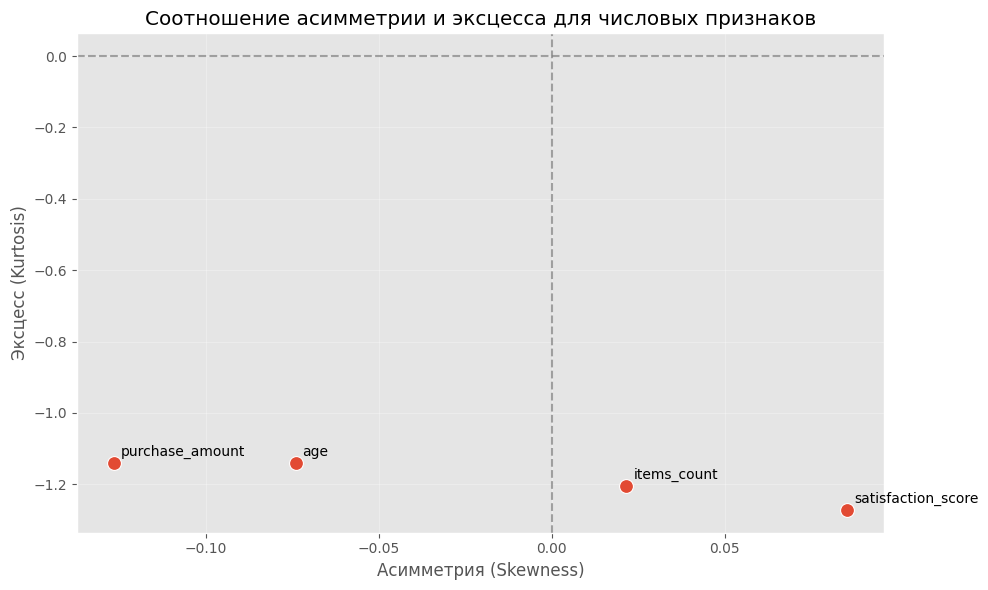


Анализ асимметрии и эксцесса:
- Положительная асимметрия: распределение с длинным правым хвостом
- Отрицательная асимметрия: распределение с длинным левым хвостом
- Положительный эксцесс: более островершинное распределение (чем нормальное)
- Отрицательный эксцесс: более плосковершинное распределение (чем нормальное)


In [35]:
# Создаем DataFrame с показателями асимметрии и эксцесса
skew_kurt_df = stats_df[['skewness', 'kurtosis']].reset_index()
skew_kurt_df.columns = ['feature', 'skewness', 'kurtosis']

# Визуализация соотношения асимметрии и эксцесса
plt.figure(figsize=(10, 6))
sns.scatterplot(data=skew_kurt_df, x='skewness', y='kurtosis', s=100)

# Добавляем подписи к точкам
for i, row in skew_kurt_df.iterrows():
    plt.annotate(row['feature'],
                (row['skewness'], row['kurtosis']),
                xytext=(5, 5), textcoords='offset points')

# Добавляем линии, разделяющие график на квадранты
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)

plt.title('Соотношение асимметрии и эксцесса для числовых признаков')
plt.xlabel('Асимметрия (Skewness)')
plt.ylabel('Эксцесс (Kurtosis)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('skew_kurt_relationship.png')
plt.show()

print("\nАнализ асимметрии и эксцесса:")
print("- Положительная асимметрия: распределение с длинным правым хвостом")
print("- Отрицательная асимметрия: распределение с длинным левым хвостом")
print("- Положительный эксцесс: более островершинное распределение (чем нормальное)")
print("- Отрицательный эксцесс: более плосковершинное распределение (чем нормальное)")

# Блок 4. Анализ категориальных данных

In [36]:
# Импорт необходимых библиотек
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, countDistinct, expr, desc, round as round_
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Загрузка обработанного датафрейма
spark = SparkSession.builder.appName("Categorical Data Analysis").getOrCreate()
df_processed = spark.read.parquet("processed_ecommerce_data")

# Проверим структуру данных
print("Схема данных:")
df_processed.printSchema()

Схема данных:
root
 |-- customer_id: string (nullable = true)
 |-- age: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- purchase_amount: float (nullable = true)
 |-- items_count: integer (nullable = true)
 |-- discount_applied: boolean (nullable = true)
 |-- satisfaction_score: integer (nullable = true)
 |-- purchase_date: timestamp (nullable = true)
 |-- shipping_address: string (nullable = true)



# 4.1. Определение категориальных колонок

In [37]:
# Определяем категориальные колонки (строковые и булевские)
categorical_columns = [field.name for field in df_processed.schema.fields
                      if field.dataType.typeName() in ['string', 'boolean']]

# Исключаем колонки с идентификаторами и адресами, которые не являются настоящими категориями
exclude_columns = ['customer_id', 'shipping_address']
categorical_columns = [col for col in categorical_columns if col not in exclude_columns]

print(f"Категориальные колонки: {categorical_columns}")

# Проверим количество уникальных значений в каждой категориальной колонке
unique_values = df_processed.select([
    countDistinct(col).alias(f"{col}_distinct_count")
    for col in categorical_columns
]).toPandas()

print("\nКоличество уникальных значений в категориальных колонках:")
for col in categorical_columns:
    print(f"- {col}: {unique_values[f'{col}_distinct_count'].iloc[0]}")

Категориальные колонки: ['gender', 'country', 'product_category', 'discount_applied']

Количество уникальных значений в категориальных колонках:
- gender: 2
- country: 8
- product_category: 6
- discount_applied: 2


# 4.2. Расчет характеристик для категориальных колонок (частота, процент)

In [40]:
# Функция для расчета частоты и процентного соотношения категорий
def calculate_category_stats(dataframe, column_name):
    # Подсчет общего количества записей
    total_count = dataframe.count()

    # Подсчет частоты каждой категории
    category_counts = dataframe.groupBy(column_name) \
        .agg(count("*").alias("count")) \
        .withColumn("percentage", expr(f"ROUND(count * 100 / {total_count}, 2)")) \
        .orderBy(desc("count"))

    return category_counts, total_count

# Создаем словарь для хранения результатов анализа
category_stats = {}

# Рассчитываем характеристики для каждой категориальной колонки
for column in categorical_columns:
    stats_df, total = calculate_category_stats(df_processed, column)
    stats_pd = stats_df.toPandas()
    category_stats[column] = {
        'dataframe': stats_pd,
        'total_count': total
    }

    print(f"\nРаспределение значений в колонке '{column}':")
    print(f"Общее количество: {total}")
    print(stats_pd.to_string(index=False))


Распределение значений в колонке 'gender':
Общее количество: 906
gender  count  percentage
     F    303       33.44
     M    302       33.33
  None    301       33.22

Распределение значений в колонке 'country':
Общее количество: 906
  country  count  percentage
    China    134       14.79
   Canada    127       14.02
Australia    126       13.91
    Japan    112       12.36
       UK    107       11.81
   France    106       11.70
      USA     98       10.82
  Germany     96       10.60

Распределение значений в колонке 'product_category':
Общее количество: 906
product_category  count  percentage
          Beauty    166       18.32
          Sports    162       17.88
  Home & Kitchen    151       16.67
        Clothing    150       16.56
           Books    149       16.45
     Electronics    128       14.13

Распределение значений в колонке 'discount_applied':
Общее количество: 906
 discount_applied  count  percentage
             True    462       50.99
            False    444

# 4.3. Визуализация категориальных данных

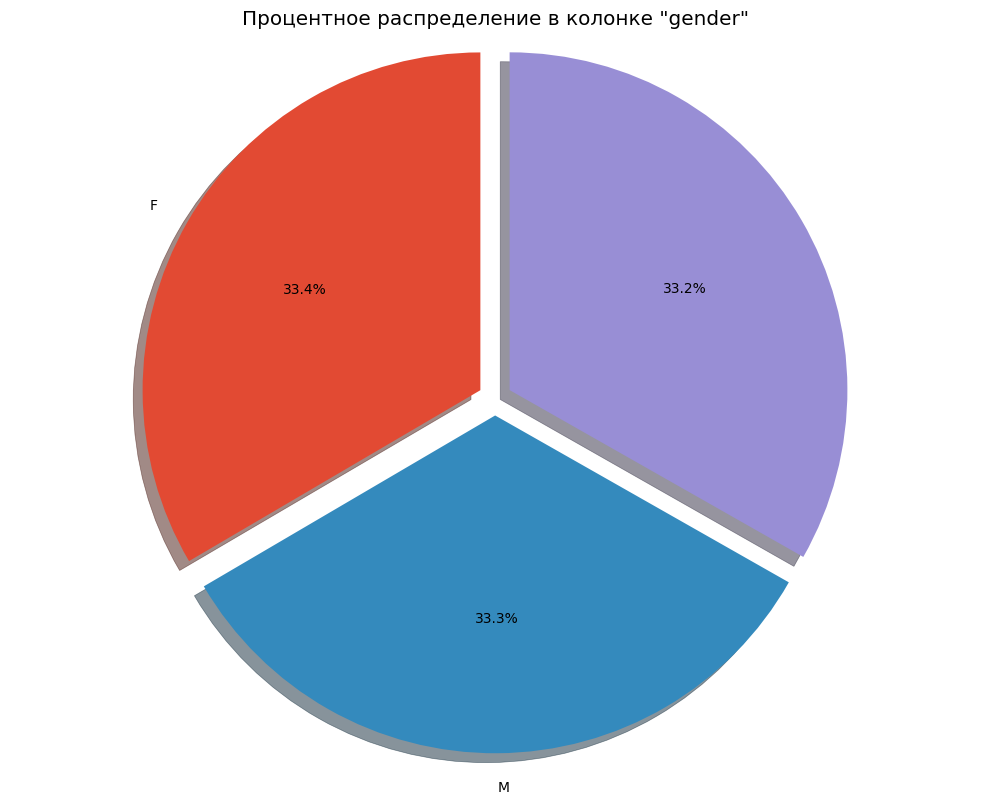

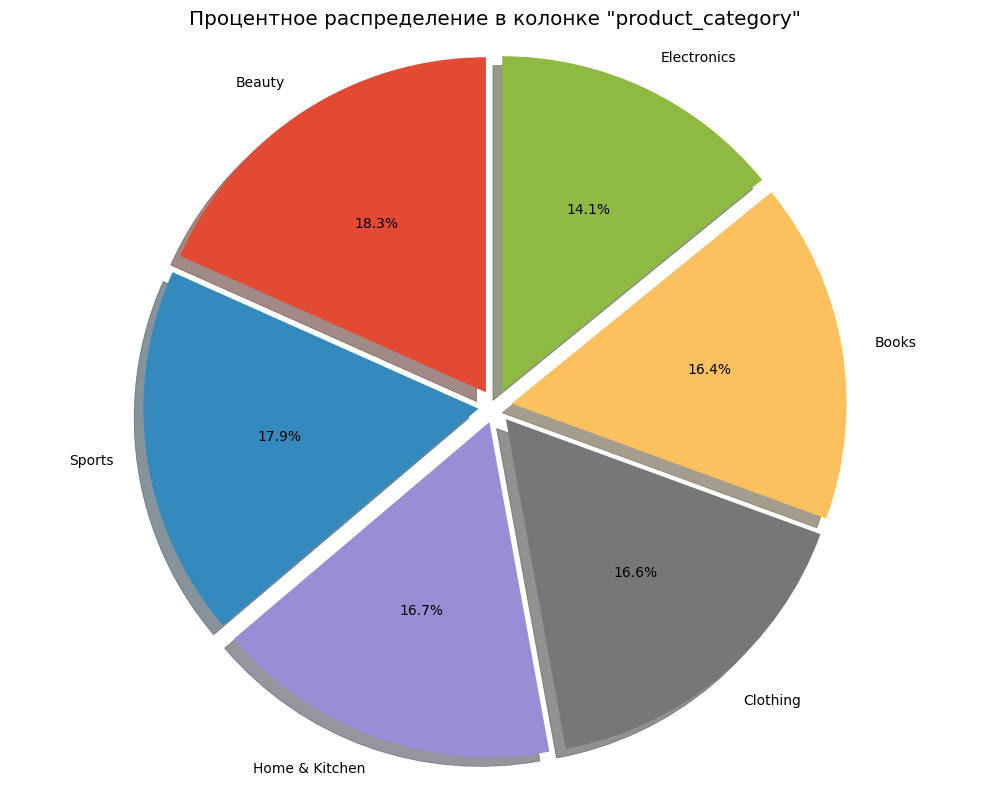

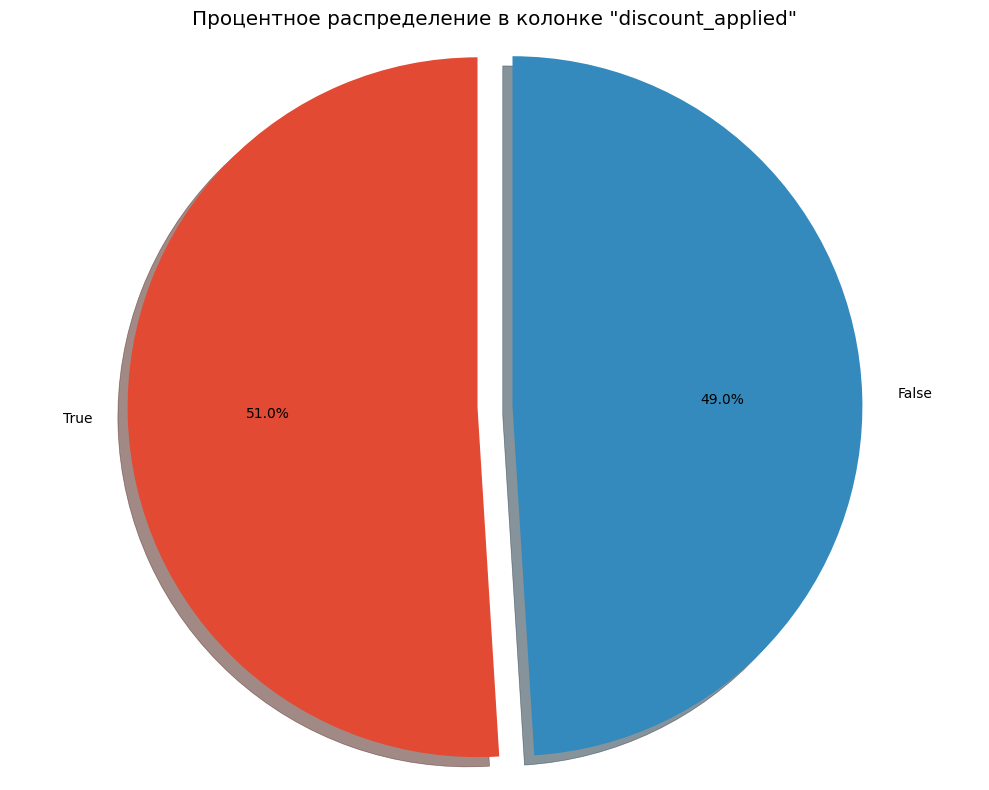

In [44]:
for column in categorical_columns:
    stats_df = category_stats[column]['dataframe']

    # Круговые диаграммы лучше использовать для небольшого числа категорий (меньше 8)
    if len(stats_df) <= 7:
        plt.figure(figsize=(10, 8))

        # Создаем круговую диаграмму
        plt.pie(stats_df['percentage'],
                labels=stats_df[column],
                autopct='%1.1f%%',
                startangle=90,
                shadow=True,
                explode=[0.05] * len(stats_df))  # Небольшое смещение всех секторов

        # Настраиваем заголовок и другие параметры
        plt.title(f'Процентное распределение в колонке "{column}"')
        plt.axis('equal')  # Обеспечивает правильные пропорции круга
        plt.tight_layout()
        plt.savefig(f'categorical_{column}_pieplot.png')
        plt.show()

##  Визуализация связей между категориальными переменными

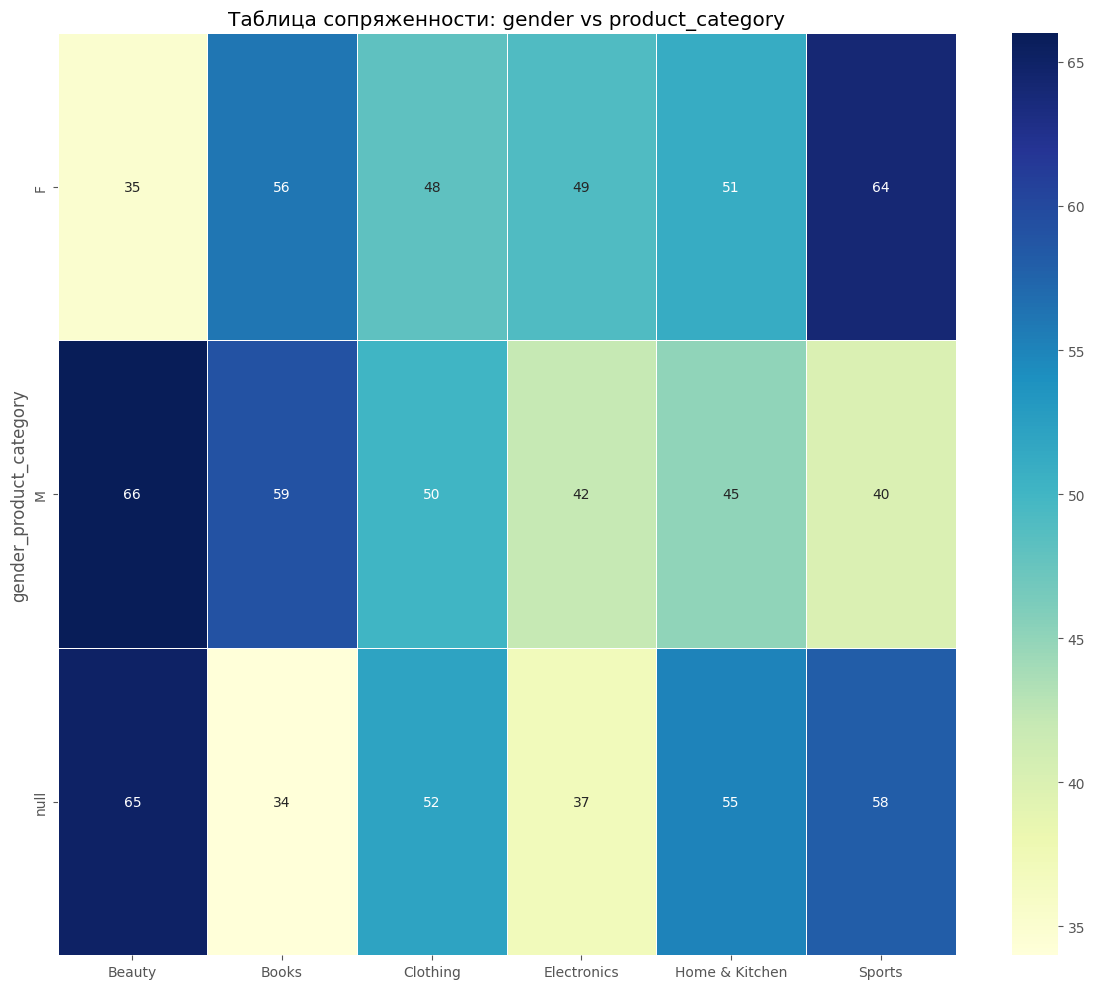

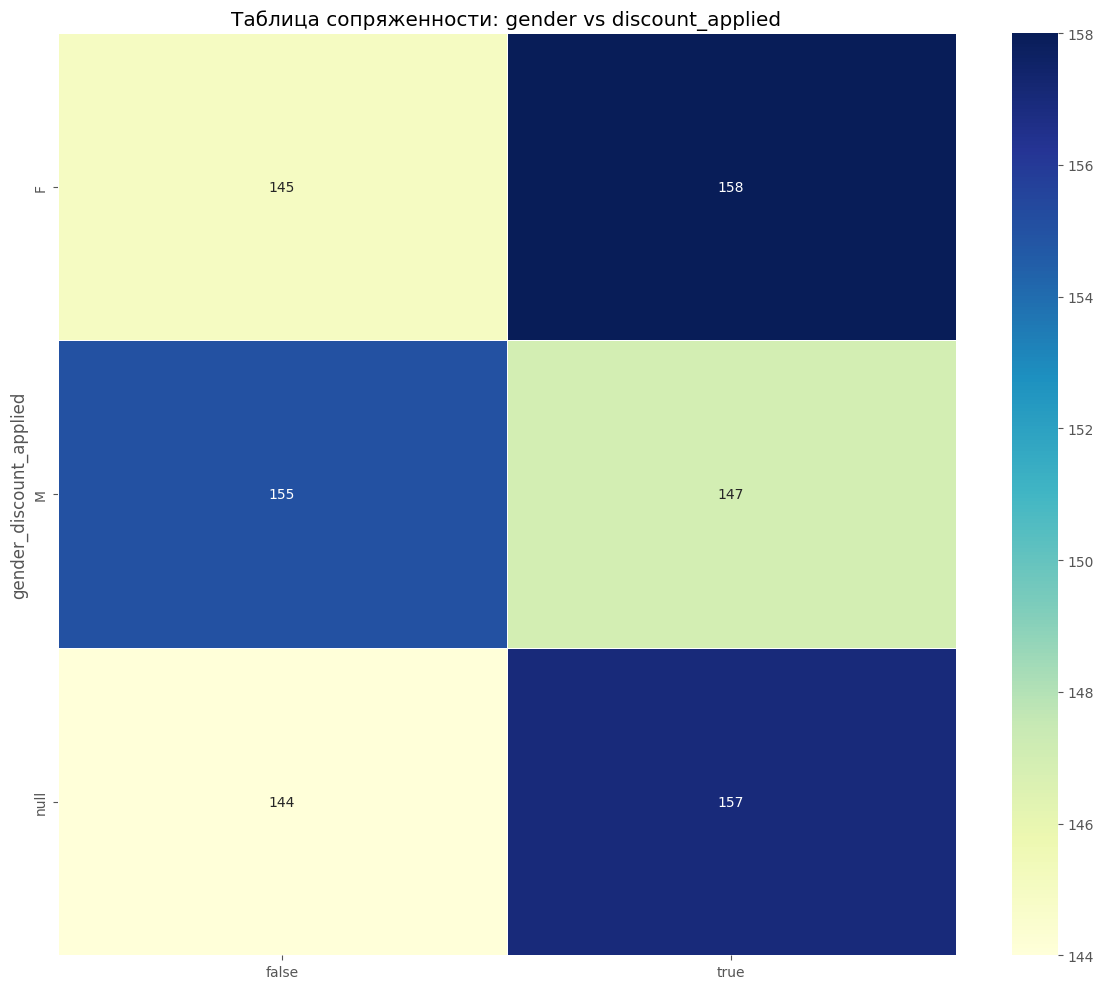

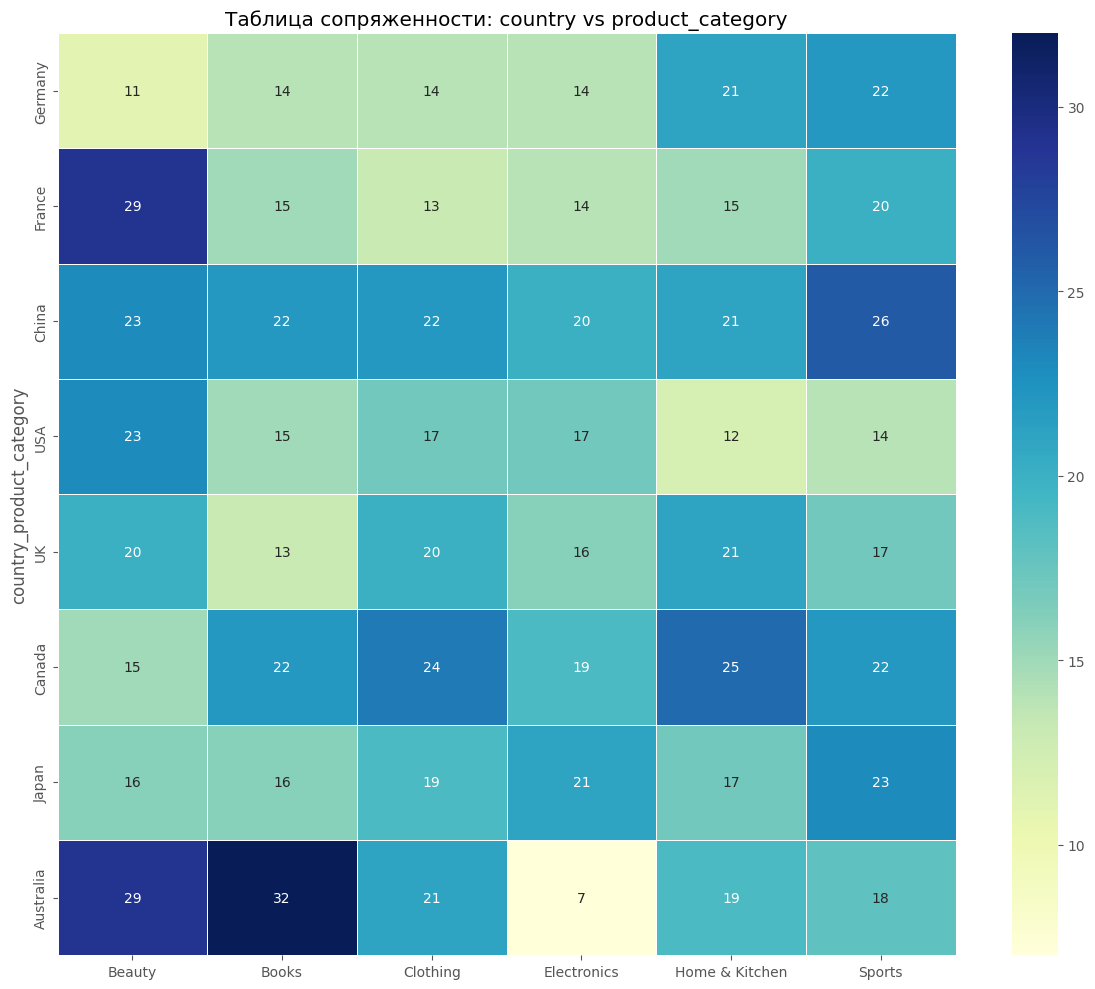

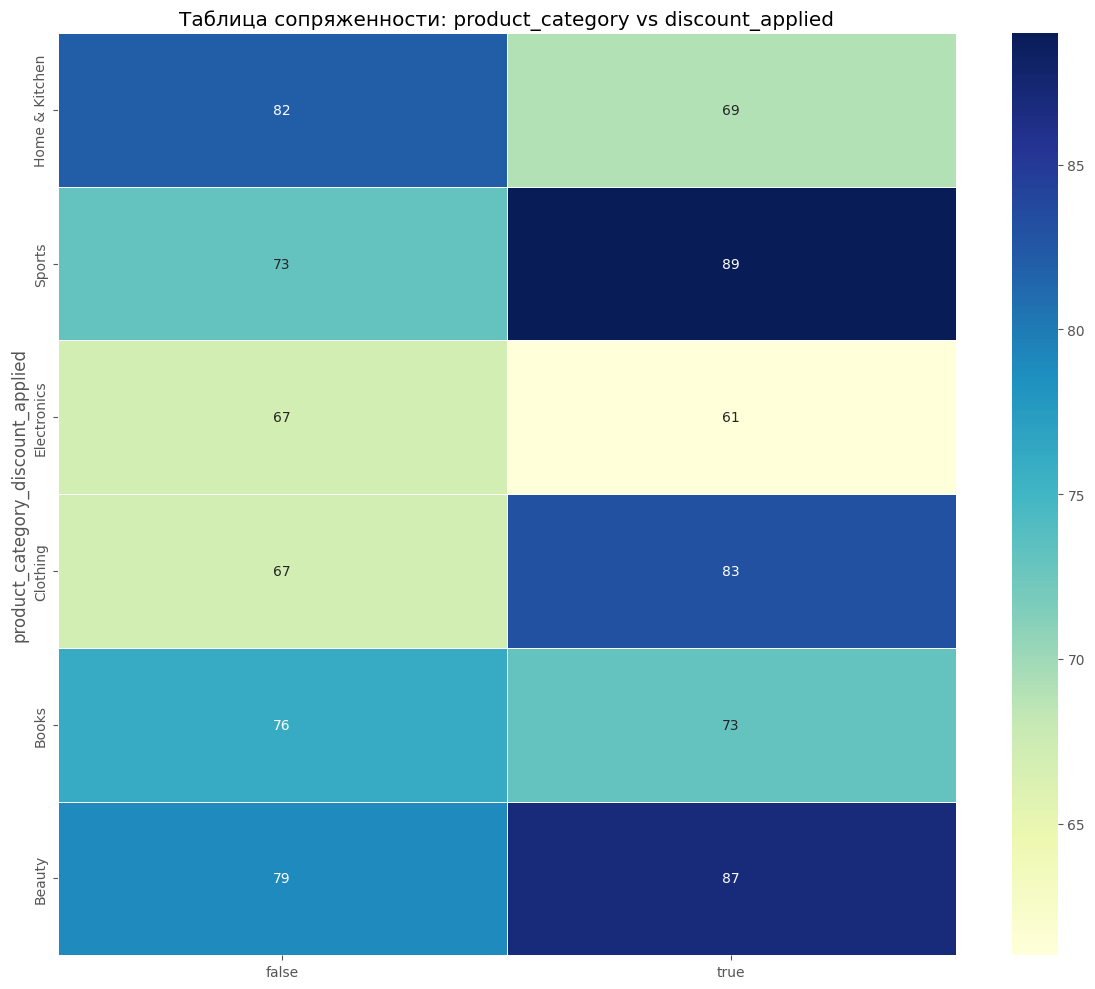

In [47]:
# Функция для создания таблицы сопряженности между двумя категориальными переменными
def create_crosstab(dataframe, col1, col2):
    # Создаем таблицу сопряженности с помощью PySpark
    ct = dataframe.crosstab(col1, col2)

    # Преобразуем в pandas для визуализации
    ct_pd = ct.toPandas()

    # Получаем правильное имя первой колонки
    first_column = ct_pd.columns[0]

    # Преобразуем формат таблицы для удобства отображения
    ct_pd = ct_pd.set_index(first_column)

    return ct_pd

# Визуализируем связи между некоторыми категориальными переменными
# Выберем несколько комбинаций для анализа
category_pairs = [
    ('gender', 'product_category'),
    ('gender', 'discount_applied'),
    ('country', 'product_category'),
    ('product_category', 'discount_applied')  # Заменил spending_category на product_category
]

for col1, col2 in category_pairs:
    if col1 in categorical_columns and col2 in categorical_columns:
        # Создаем таблицу сопряженности
        crosstab_df = create_crosstab(df_processed, col1, col2)

        # Визуализируем таблицу с помощью тепловой карты
        plt.figure(figsize=(12, 10))
        sns.heatmap(crosstab_df, annot=True, cmap="YlGnBu", fmt='d', linewidths=0.5)
        plt.title(f'Таблица сопряженности: {col1} vs {col2}')
        plt.tight_layout()
        plt.savefig(f'crosstab_{col1}_{col2}.png')
        plt.show()

# Блок 5. Применение ML

In [50]:
# Импорт необходимых библиотек
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.regression import LinearRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import BinaryClassificationEvaluator, RegressionEvaluator, ClusteringEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Загрузка обработанных данных
spark = SparkSession.builder.appName("ML Application").getOrCreate()
df_processed = spark.read.parquet("processed_ecommerce_data")

# Проверка доступных колонок
print("Схема данных:")
df_processed.printSchema()

Схема данных:
root
 |-- customer_id: string (nullable = true)
 |-- age: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- purchase_amount: float (nullable = true)
 |-- items_count: integer (nullable = true)
 |-- discount_applied: boolean (nullable = true)
 |-- satisfaction_score: integer (nullable = true)
 |-- purchase_date: timestamp (nullable = true)
 |-- shipping_address: string (nullable = true)



# 5.1. Подготовка данных для машинного обучения

In [51]:
# 5.1.1 Преобразование категориальных признаков
# Список категориальных признаков для преобразования
categorical_features = ['gender', 'country', 'product_category']

# Создаем индексаторы для категориальных признаков
indexers = [StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="skip")
            for col in categorical_features]

# Создаем кодировщики one-hot для индексированных признаков
encoders = [OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_vec")
            for col in categorical_features]

# 5.1.2 Выбор числовых признаков
numeric_features = ['age', 'items_count', 'satisfaction_score']

# 5.1.3 Подготовка целевых переменных
# Для классификации: был ли предоставлен дисконт (discount_applied)
# Для регрессии: сумма покупки (purchase_amount)

# 5.1.4 Разделение данных на обучающую и тестовую выборки
train_data, test_data = df_processed.randomSplit([0.8, 0.2], seed=42)
print(f"Обучающая выборка: {train_data.count()} записей")
print(f"Тестовая выборка: {test_data.count()} записей")

Обучающая выборка: 758 записей
Тестовая выборка: 148 записей


# 5.2. Предсказание суммы покупки (Регрессия)

Пример предсказаний регрессионной модели:
+---------------+------------------+
|purchase_amount|        prediction|
+---------------+------------------+
|         202.56|312.23546562077587|
|          75.59| 203.1634801550423|
|          46.93|307.41079599589153|
|          365.8|217.99229258773693|
|         440.33| 242.1152515781014|
+---------------+------------------+
only showing top 5 rows

RMSE для модели линейной регрессии: 148.6228
R² для модели линейной регрессии: -0.0560


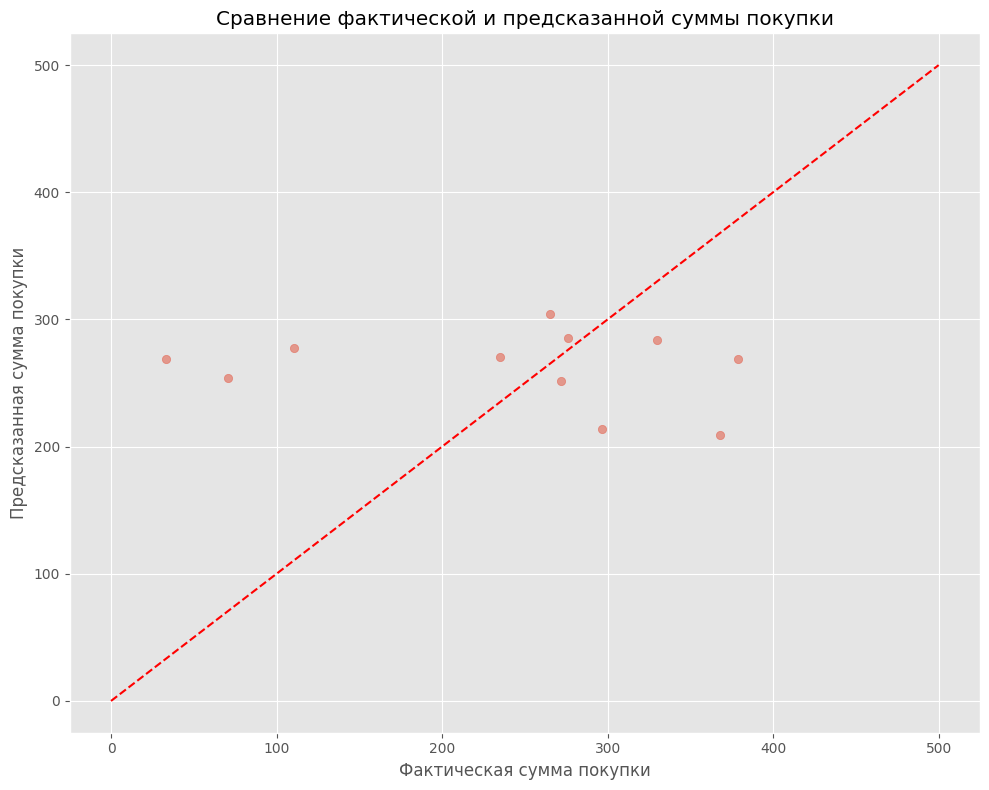

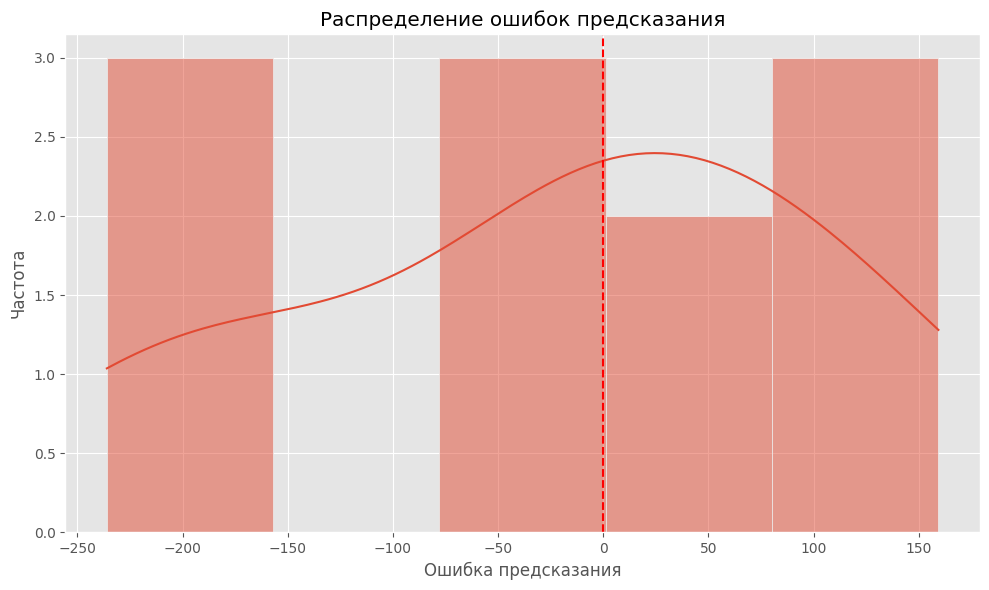

In [54]:
# 5.2.1 Подготовка пайплайна для регрессии
# Векторный ассемблер для объединения всех признаков в один вектор
assembler_reg = VectorAssembler(
    inputCols=[f"{col}_vec" for col in categorical_features] + numeric_features + ['discount_applied'],
    outputCol="features"
)

# Масштабирование признаков
scaler_reg = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

# Модель линейной регрессии
lr_reg = LinearRegression(
    featuresCol="scaled_features",
    labelCol="purchase_amount",
    maxIter=10,
    regParam=0.1,
    elasticNetParam=0.8
)

# Построение пайплайна
pipeline_reg = Pipeline(stages=indexers + encoders + [assembler_reg, scaler_reg, lr_reg])

# 5.2.2 Обучение модели
model_reg = pipeline_reg.fit(train_data)

# 5.2.3 Оценка модели на тестовой выборке
predictions_reg = model_reg.transform(test_data)

# Просмотр предсказаний
print("Пример предсказаний регрессионной модели:")
predictions_reg.select("purchase_amount", "prediction").show(5)

# Оценка качества модели
evaluator_reg = RegressionEvaluator(
    predictionCol="prediction",
    labelCol="purchase_amount",
    metricName="rmse"
)

rmse = evaluator_reg.evaluate(predictions_reg)
print(f"RMSE для модели линейной регрессии: {rmse:.4f}")

r2 = evaluator_reg.setMetricName("r2").evaluate(predictions_reg)
print(f"R² для модели линейной регрессии: {r2:.4f}")

# 5.2.4 Визуализация предсказаний и фактических значений
predictions_sample = predictions_reg.select("purchase_amount", "prediction").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(10, 8))
plt.scatter(predictions_sample["purchase_amount"], predictions_sample["prediction"], alpha=0.5)
plt.plot([0, 500], [0, 500], 'r--')  # Линия идеального предсказания
plt.xlabel('Фактическая сумма покупки')
plt.ylabel('Предсказанная сумма покупки')
plt.title('Сравнение фактической и предсказанной суммы покупки')
plt.tight_layout()
plt.savefig('regression_predictions.png')
plt.show()

# Распределение ошибок
predictions_sample['error'] = predictions_sample["purchase_amount"] - predictions_sample["prediction"]

plt.figure(figsize=(10, 6))
sns.histplot(predictions_sample['error'], kde=True)
plt.xlabel('Ошибка предсказания')
plt.ylabel('Частота')
plt.title('Распределение ошибок предсказания')
plt.axvline(0, color='r', linestyle='--')
plt.tight_layout()
plt.savefig('regression_errors.png')
plt.show()

# 5.3. Кластеризация клиентов (Clustering)

In [55]:
# 5.3.1 Подготовка данных для кластеризации
# Выберем признаки для кластеризации
clustering_features = numeric_features + ['purchase_amount']

# Векторный ассемблер для объединения признаков
assembler_clust = VectorAssembler(
    inputCols=clustering_features,
    outputCol="features"
)

# Масштабирование признаков обязательно для k-means
scaler_clust = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

# 5.4.2 Определение оптимального количества кластеров
# Рассчитаем показатель Silhouette для разного числа кластеров
silhouette_scores = []
k_values = range(2, 8)

# Подготовка данных
clustering_pipeline = Pipeline(stages=[assembler_clust, scaler_clust])
clustering_model = clustering_pipeline.fit(df_processed)
prepared_data = clustering_model.transform(df_processed)

# Для каждого k оцениваем качество кластеризации
for k in k_values:
    kmeans = KMeans(featuresCol="scaled_features", k=k, seed=42)
    model = kmeans.fit(prepared_data)
    predictions = model.transform(prepared_data)

    # Рассчитываем Silhouette Score
    evaluator = ClusteringEvaluator(
        predictionCol="prediction",
        featuresCol="scaled_features",
        metricName="silhouette"
    )

    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)
    print(f"Силуэтный коэффициент для k={k}: {silhouette:.4f}")

#

Силуэтный коэффициент для k=2: 0.3021
Силуэтный коэффициент для k=3: 0.2825
Силуэтный коэффициент для k=4: 0.3087
Силуэтный коэффициент для k=5: 0.3283
Силуэтный коэффициент для k=6: 0.3268
Силуэтный коэффициент для k=7: 0.3515
